### Testing image statistics

In [26]:
from caxscripts.image_statistics import Histogram2DAnalyzer
import h5py
import numpy as np
import os
import re
import matplotlib.pyplot as plt

In [27]:
def h5_to_dict(filename):
    """Read an HDF5 file into a nested dict.

    Structure:
        data[group_name]['attrs']        -> group attributes (metadata)
        data[group_name][dataset_name]   -> dict with 'data' (numpy array)
                                           and 'attrs' (dataset attributes)
    """
    def _read_group(grp):
        out = {'attrs': dict(grp.attrs)}
        for name, item in grp.items():
            if isinstance(item, h5py.Dataset):
                out[name] = {'data': item[()], 'attrs': dict(item.attrs)}
            elif isinstance(item, h5py.Group):
                out[name] = _read_group(item)
        return out

    with h5py.File(filename, 'r') as f:
        return {key: _read_group(f[key]) for key in f}


def data_from_h5_files(files):
    """Read multiple HDF5 files into a nested dict."""
    data = {}
    for filename in files:
        key = re.sub('pass', '', os.path.basename(filename).split('_')[2].split('-')[0])
        data[key] = h5_to_dict(filename)
    return data


def files_in_directory(wdir, pattern):
    """List files in a directory matching a regex pattern."""
    rawfiles = os.listdir(wdir)
    return sorted([f"{wdir}/{f}" for f in rawfiles if re.match(pattern, f)])


In [28]:
workdir = "/home/gabriel.amici/testing_data/2026-03-19"
file_pattern = r"mirror_tx_pass0*"


### Files from the TX scans performed @ 2026-03-19

In [29]:
def main(workdir, file_pattern):
      files = files_in_directory(workdir, file_pattern)
      data  = data_from_h5_files(files)

      print(f"Loaded {len(files)} files matching pattern '{file_pattern}' from '{workdir}'"
            "\n Files:")
      for f in files:
            print(f" * {f}")

      return data

data = main(workdir, file_pattern)

Loaded 11 files matching pattern 'mirror_tx_pass0*' from '/home/gabriel.amici/testing_data/2026-03-19'
 Files:
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass01-20260319_135203.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass02-20260319_140127.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass03-20260319_140815.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass04-20260319_141205.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass05-20260319_141544.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass06-20260319_141935.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass07-20260319_142327.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass08-20260319_142753.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass09-20260319_143126.hdf5
 * /home/gabriel.amici/testing_data/2026-03-19/mirror_tx_pass10-20260319_143508.hdf5
 * /home/gabriel.amici/testing_data/202

### Sample image

In [30]:
test_img = data['01']['scan-0000']['dvf_B1']['data'].T

In [31]:
ana_scan = Histogram2DAnalyzer(img=test_img,
                          xedges=np.arange(test_img.shape[0]+1),
                          yedges=np.arange(test_img.shape[1]+1))

In [32]:
ana_scan.compute_moments()

{'mux': 2409.4505363841054,
 'muy': 1268.8599630234787,
 'cov': array([[11709.54693851,   447.6189111 ],
        [  447.6189111 ,  7804.77874338]]),
 'sigx': 108.21066000404261,
 'sigy': 88.3446588276779,
 'sig_major': 108.44446560402146,
 'sig_minor': 88.05750145074252,
 'theta': -3.0289061961171995,
 'evecs': array([[-0.9936576 ,  0.11244812],
        [-0.11244812, -0.9936576 ]]),
 'xcenters': array([5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 3.0855e+03, 3.0865e+03,
        3.0875e+03]),
 'ycenters': array([5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0615e+03, 2.0625e+03,
        2.0635e+03])}

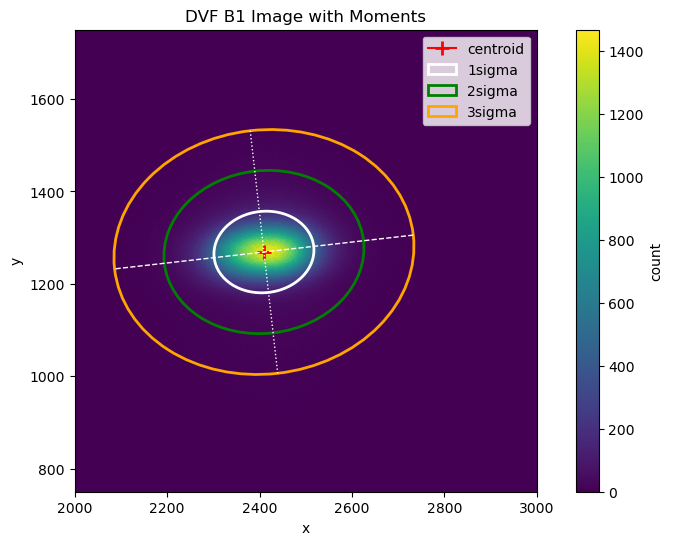

In [33]:
fig, ax = ana_scan.plot()
ax.set_xlim(2000, 3000)
ax.set_ylim(750, 1750)
ax.set_title("DVF B1 Image with Moments")
plt.show()


Background noise destroys the accuracy provided by the moments of this histogram. We can see the difference by fitting a Gaussian distribution using the moments as guesses 

In [34]:
ana_scan.fit()

{'mux': 2412.119948847288,
 'muy': 1270.7304381474319,
 'sigx': 79.80265764558595,
 'sigy': 42.370826731332954,
 'cov': array([[6368.4641673 ,  190.61026497],
        [ 190.61026497, 1795.2869579 ]]),
 'sig_major': 79.85233283501533,
 'sig_minor': 42.27713407979743,
 'theta': -3.1000087444199544,
 'evecs': array([[-0.99913551,  0.04157193],
        [-0.04157193, -0.99913551]]),
 'xcenters': array([5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 3.0855e+03, 3.0865e+03,
        3.0875e+03]),
 'ycenters': array([5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0615e+03, 2.0625e+03,
        2.0635e+03])}

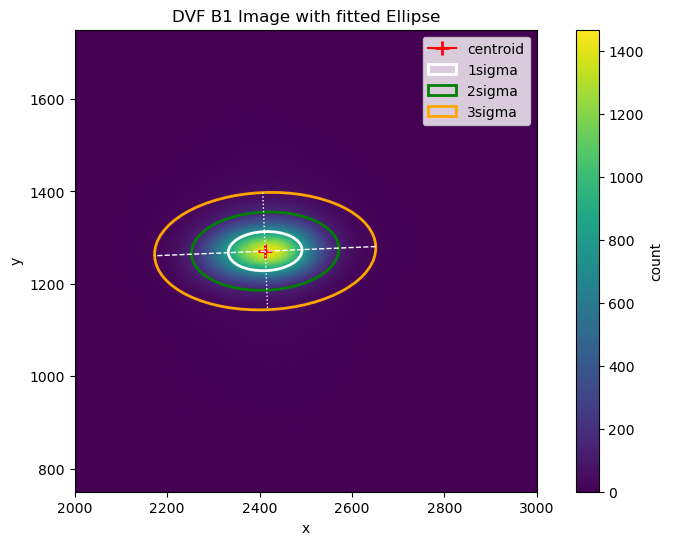

In [35]:
fig, ax = ana_scan.plot()
ax.set_xlim(2000, 3000)
ax.set_ylim(750, 1750)
ax.set_title("DVF B1 Image with fitted Ellipse")
plt.show()

The improvement is evident, at the cost of computation time (which can be improved by first defining a ROI inside of which the fitting shall take place).

An alternative is to first compute the optimal threshold and then calculate the moments:

In [36]:
ana_scan.compute_threshold()

(array([3.71852496, 4.00272569, 4.08075545, 4.08519868, 4.05909803,
        4.01174352, 3.95202276, 3.87667781, 3.79034202, 3.69404778,
        3.58570338, 3.46604738, 3.32999431, 3.17818682, 3.00671185,
        2.80588655, 2.57375557, 2.29643287, 1.94995794, 1.48881389,
        0.82540872, 0.11684867]),
 array([   0.        ,   63.73913043,  127.47826087,  191.2173913 ,
         254.95652174,  318.69565217,  382.43478261,  446.17391304,
         509.91304348,  573.65217391,  637.39130435,  701.13043478,
         764.86956522,  828.60869565,  892.34782609,  956.08695652,
        1019.82608696, 1083.56521739, 1147.30434783, 1211.04347826,
        1274.7826087 , 1338.52173913, 1402.26086957, 1466.        ]),
 191.2173913043478,
 23)

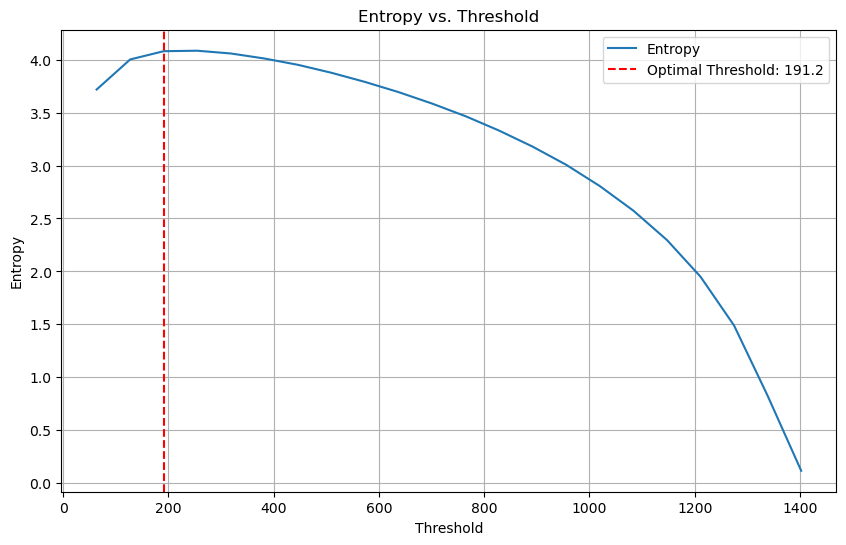

In [37]:
entropies, bin_edges, optimal_threshold, _ = ana_scan.compute_threshold()
ana_scan.plot_entropy(entropies, bin_edges, optimal_threshold)
plt.show()

Now we can define a new Analyzer whose image is just the foreground of `ana-scan.img`

In [38]:
ana_scan_thrs = Histogram2DAnalyzer(img=ana_scan.img_thresholded,
                                    xedges=ana_scan.xedges,
                                    yedges=ana_scan.yedges)

In [39]:
ana_scan_thrs.compute_moments()

{'mux': 2411.0044365808003,
 'muy': 1270.9095075940254,
 'cov': array([[3800.47911115,  123.80097984],
        [ 123.80097984, 1076.32942969]]),
 'sigx': 61.648026011825884,
 'sigy': 32.80745997017943,
 'sig_major': 61.693547193265246,
 'sig_minor': 32.72177830684085,
 'theta': -3.096271449947377,
 'evecs': array([[-0.99897317,  0.04530569],
        [-0.04530569, -0.99897317]]),
 'xcenters': array([5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 3.0855e+03, 3.0865e+03,
        3.0875e+03]),
 'ycenters': array([5.0000e-01, 1.5000e+00, 2.5000e+00, ..., 2.0615e+03, 2.0625e+03,
        2.0635e+03])}

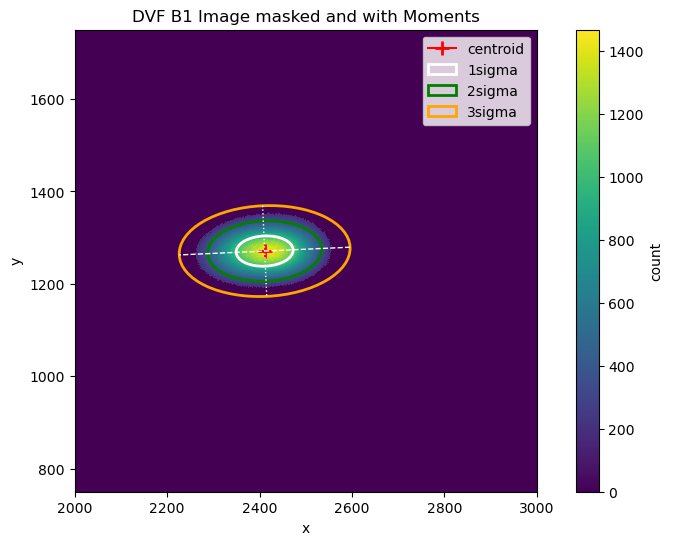

In [40]:
fig, ax = ana_scan_thrs.plot()
ax.set_title("DVF B1 Image masked and with Moments")
ax.set_xlim(2000, 3000)
ax.set_ylim(750, 1750)
plt.show()

The result is more similar to the fitted parameters of the original `ana_scan`, but sigmas are subestimated: threshold value seems to be too high, eliminating parts of the light halo around the beam image:

In [41]:
ana_scan.print_stats()

mu         = (2.4121e+03, 1.2707e+03)
sigma x    = 7.9803e+01
sigma y    = 4.2371e+01
xy cov     = 1.9061e+02

principal sigmas:
    sigma minor = 42.27713407979743
    sigma major = 79.85233283501533

theta = -3.1000e+00 rad = -1.7762e+02 deg

cov matrix:
[[6368.4641673   190.61026497]
 [ 190.61026497 1795.2869579 ]]


In [42]:
ana_scan_thrs.print_stats()

mu         = (2.4110e+03, 1.2709e+03)
sigma x    = 6.1648e+01
sigma y    = 3.2807e+01
xy cov     = 1.2380e+02

principal sigmas:
    sigma minor = 32.72177830684085
    sigma major = 61.693547193265246

theta = -3.0963e+00 rad = -1.7740e+02 deg

cov matrix:
[[3800.47911115  123.80097984]
 [ 123.80097984 1076.32942969]]
